In [36]:
import tensorflow as tf

In [37]:
# Data Pre-processing
_URL = 'https://storage.googleapis.com/mledu-datasets/cats_and_dogs_filtered.zip'

data_path = tf.keras.utils.get_file(origin=_URL,  cache_dir="." ,fname="cat_vs_dogs", extract=True)


In [38]:
from pathlib import Path

data_path = Path(data_path)

data_path = data_path/"cats_and_dogs_filtered"

data_path

train_data = data_path/"train"
val_data = data_path/"validation"

In [39]:
# Create td.data Dataset
IMAGE_SIZE = (160,160)

train_ds = tf.keras.utils.image_dataset_from_directory(directory=train_data, validation_split=0.2, batch_size=32, subset="training", seed=42, shuffle=True, image_size=IMAGE_SIZE)
val_ds = tf.keras.utils.image_dataset_from_directory(directory=val_data, validation_split=0.2, subset="validation", batch_size=32, seed=42, image_size=IMAGE_SIZE)



Found 2000 files belonging to 2 classes.
Using 1600 files for training.
Found 1000 files belonging to 2 classes.
Using 200 files for validation.


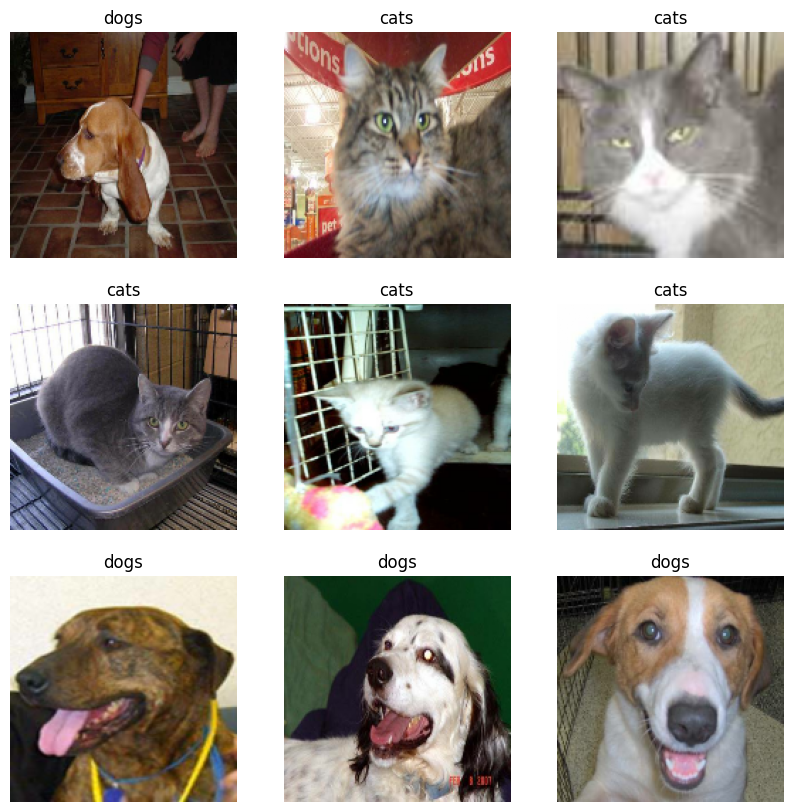

In [40]:

class_names = train_ds.class_names

import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))

for img,label in train_ds.take(1):
    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow(img[i]/255.0)
        plt.title(class_names[label[i]])
        plt.axis("off")
    



In [41]:
class_names

['cats', 'dogs']

In [42]:
print('Number of validation batches: %d' % tf.data.experimental.cardinality(val_ds))
print('Number of train batches: %d' % tf.data.experimental.cardinality(train_ds))

Number of validation batches: 7
Number of train batches: 50


In [43]:
val_batchs = tf.data.experimental.cardinality(val_ds)
test_ds = val_ds.take(val_batchs // 5)
val_ds = val_ds.skip(val_batchs // 5)


In [44]:
print('Number of validation batches: %d' % tf.data.experimental.cardinality(val_ds))
print('Number of train batches: %d' % tf.data.experimental.cardinality(train_ds))
print('Number of test batches: %d' % tf.data.experimental.cardinality(test_ds))

Number of validation batches: 6
Number of train batches: 50
Number of test batches: 1


In [45]:
## performnce
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)


In [46]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2)
])

In [47]:
data_augmentation

<Sequential name=sequential_1, built=False>

In [48]:
for image,_ in train_ds.take(1):
    test_img = image[0]

2025-06-30 19:28:11.343131: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [49]:
test_img

<tf.Tensor: shape=(160, 160, 3), dtype=float32, numpy=
array([[[  9.4625   ,  23.4625   ,   1.9812499],
        [ 20.721874 ,  34.351562 ,  11.684374 ],
        [  8.4921875,  21.257812 ,   6.6640625],
        ...,
        [  2.265625 ,   9.1171875,   9.3515625],
        [  3.259369 ,  16.296844 ,  15.037476 ],
        [  6.259384 ,  24.142204 ,  22.895332 ]],

       [[ 30.315624 ,  44.192184 ,  20.932812 ],
        [ 17.832813 ,  30.9625   ,  12.554687 ],
        [ 12.6328125,  22.875    ,  11.8671875],
        ...,
        [  2.265625 ,  10.296875 ,   3.8828125],
        [  1.       ,  14.129684 ,   5.3703156],
        [  1.       ,  14.123436 ,   5.753128 ]],

       [[ 19.221874 ,  31.721874 ,  15.845312 ],
        [ 27.110937 ,  39.240623 ,  25.592188 ],
        [ 20.03125  ,  31.796875 ,  21.734375 ],
        ...,
        [  5.9921875,  17.375    ,   3.7578125],
        [  1.6296844,  12.407791 ,   1.0187378],
        [  4.259384 ,  20.271896 ,   7.7718964]],

       ...,

     

In [50]:
tf.reduce_max(test_img)

<tf.Tensor: shape=(), dtype=float32, numpy=247.11563110351562>

In [51]:
process_inp = tf.keras.applications.mobilenet_v2.preprocess_input


new_img = process_inp(test_img)
new_img

<tf.Tensor: shape=(160, 160, 3), dtype=float32, numpy=
array([[[-0.92578435, -0.8159804 , -0.9844608 ],
        [-0.8374755 , -0.730576  , -0.90835786],
        [-0.9333946 , -0.83327204, -0.94773287],
        ...,
        [-0.98223037, -0.92849267, -0.9266544 ],
        [-0.97443634, -0.8721816 , -0.88205904],
        [-0.9509068 , -0.8106494 , -0.8204287 ]],

       [[-0.7622304 , -0.65339464, -0.8358211 ],
        [-0.8601348 , -0.75715685, -0.9015319 ],
        [-0.90091914, -0.82058823, -0.906924  ],
        ...,
        [-0.98223037, -0.9192402 , -0.96954656],
        [-0.99215686, -0.88917893, -0.9578799 ],
        [-0.99215686, -0.889228  , -0.95487744]],

       [[-0.8492402 , -0.751201  , -0.87572306],
        [-0.7873652 , -0.6922304 , -0.79927695],
        [-0.84289217, -0.75061274, -0.8295343 ],
        ...,
        [-0.95300245, -0.8637255 , -0.97052693],
        [-0.98721814, -0.902684  , -0.9920099 ],
        [-0.9665931 , -0.8410047 , -0.93904394]],

       ...,

     

In [52]:
tf.reduce_min(new_img)

<tf.Tensor: shape=(), dtype=float32, numpy=-1.0>

In [53]:
base_model = tf.keras.applications.MobileNetV2(input_shape=(160,160,3), include_top=False)

In [54]:
base_model.summary()

Model: "mobilenetv2_1.00_160"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 160, 160,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 80, 80,    │        864 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 80, 80,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 80, 80,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 80, 80,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 80, 80,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 80, 80,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 80, 80,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 80, 80,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 80, 80,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 80, 80,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 80, 80,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 81, 81,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 40, 40,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 40, 40,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 40, 40,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 40, 40,    │      2,304 │ block_1_depthwis

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 2,223,872 (8.48 MB)

 Non-trainable params: 34,112 (133.25 KB)

In [55]:
image_batch, label_batch = next(iter(train_ds))

image_batch.shape

feature_batch = base_model(image_batch)

In [56]:
feature_batch.shape

TensorShape([32, 5, 5, 1280])

In [57]:
global_average_layer = tf.keras.layers.GlobalAveragePooling2D()

a  =global_average_layer(feature_batch)

In [58]:
prediction_layer = tf.keras.layers.Dense(1, activation="sigmoid")

prediction_layer(a)

<tf.Tensor: shape=(32, 1), dtype=float32, numpy=
array([[0.6917339 ],
       [0.35094407],
       [0.66725963],
       [0.7465534 ],
       [0.23233949],
       [0.6373149 ],
       [0.5972036 ],
       [0.36573458],
       [0.33209044],
       [0.7089757 ],
       [0.6096664 ],
       [0.76070035],
       [0.8161969 ],
       [0.7379377 ],
       [0.6664872 ],
       [0.7793737 ],
       [0.83597356],
       [0.7578855 ],
       [0.5014204 ],
       [0.82387793],
       [0.55144733],
       [0.42991152],
       [0.64858174],
       [0.8391435 ],
       [0.57195425],
       [0.5040628 ],
       [0.8221505 ],
       [0.6398924 ],
       [0.36687732],
       [0.39541534],
       [0.57631725],
       [0.4662789 ]], dtype=float32)>

In [59]:
base_model.trainable = False

In [60]:
inputs = tf.keras.Input(shape=(160,160,3))
x = data_augmentation(inputs)
x = process_inp(x)
x = base_model(x, training= False)
x = global_average_layer(x)
x = tf.keras.layers.Dropout(0.2)(x)
outputs = prediction_layer(x)

model = tf.keras.Model(inputs, outputs)


In [61]:
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_1 (Subtract)           │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [62]:
model.trainable_variables

[<Variable path=dense_1/kernel, shape=(1280, 1), dtype=float32, value=[[-0.05417988]
  [-0.0563673 ]
  [-0.00925908]
  ...
  [-0.03731631]
  [-0.04345183]
  [-0.06106685]]>,
 <Variable path=dense_1/bias, shape=(1,), dtype=float32, value=[0.]>]

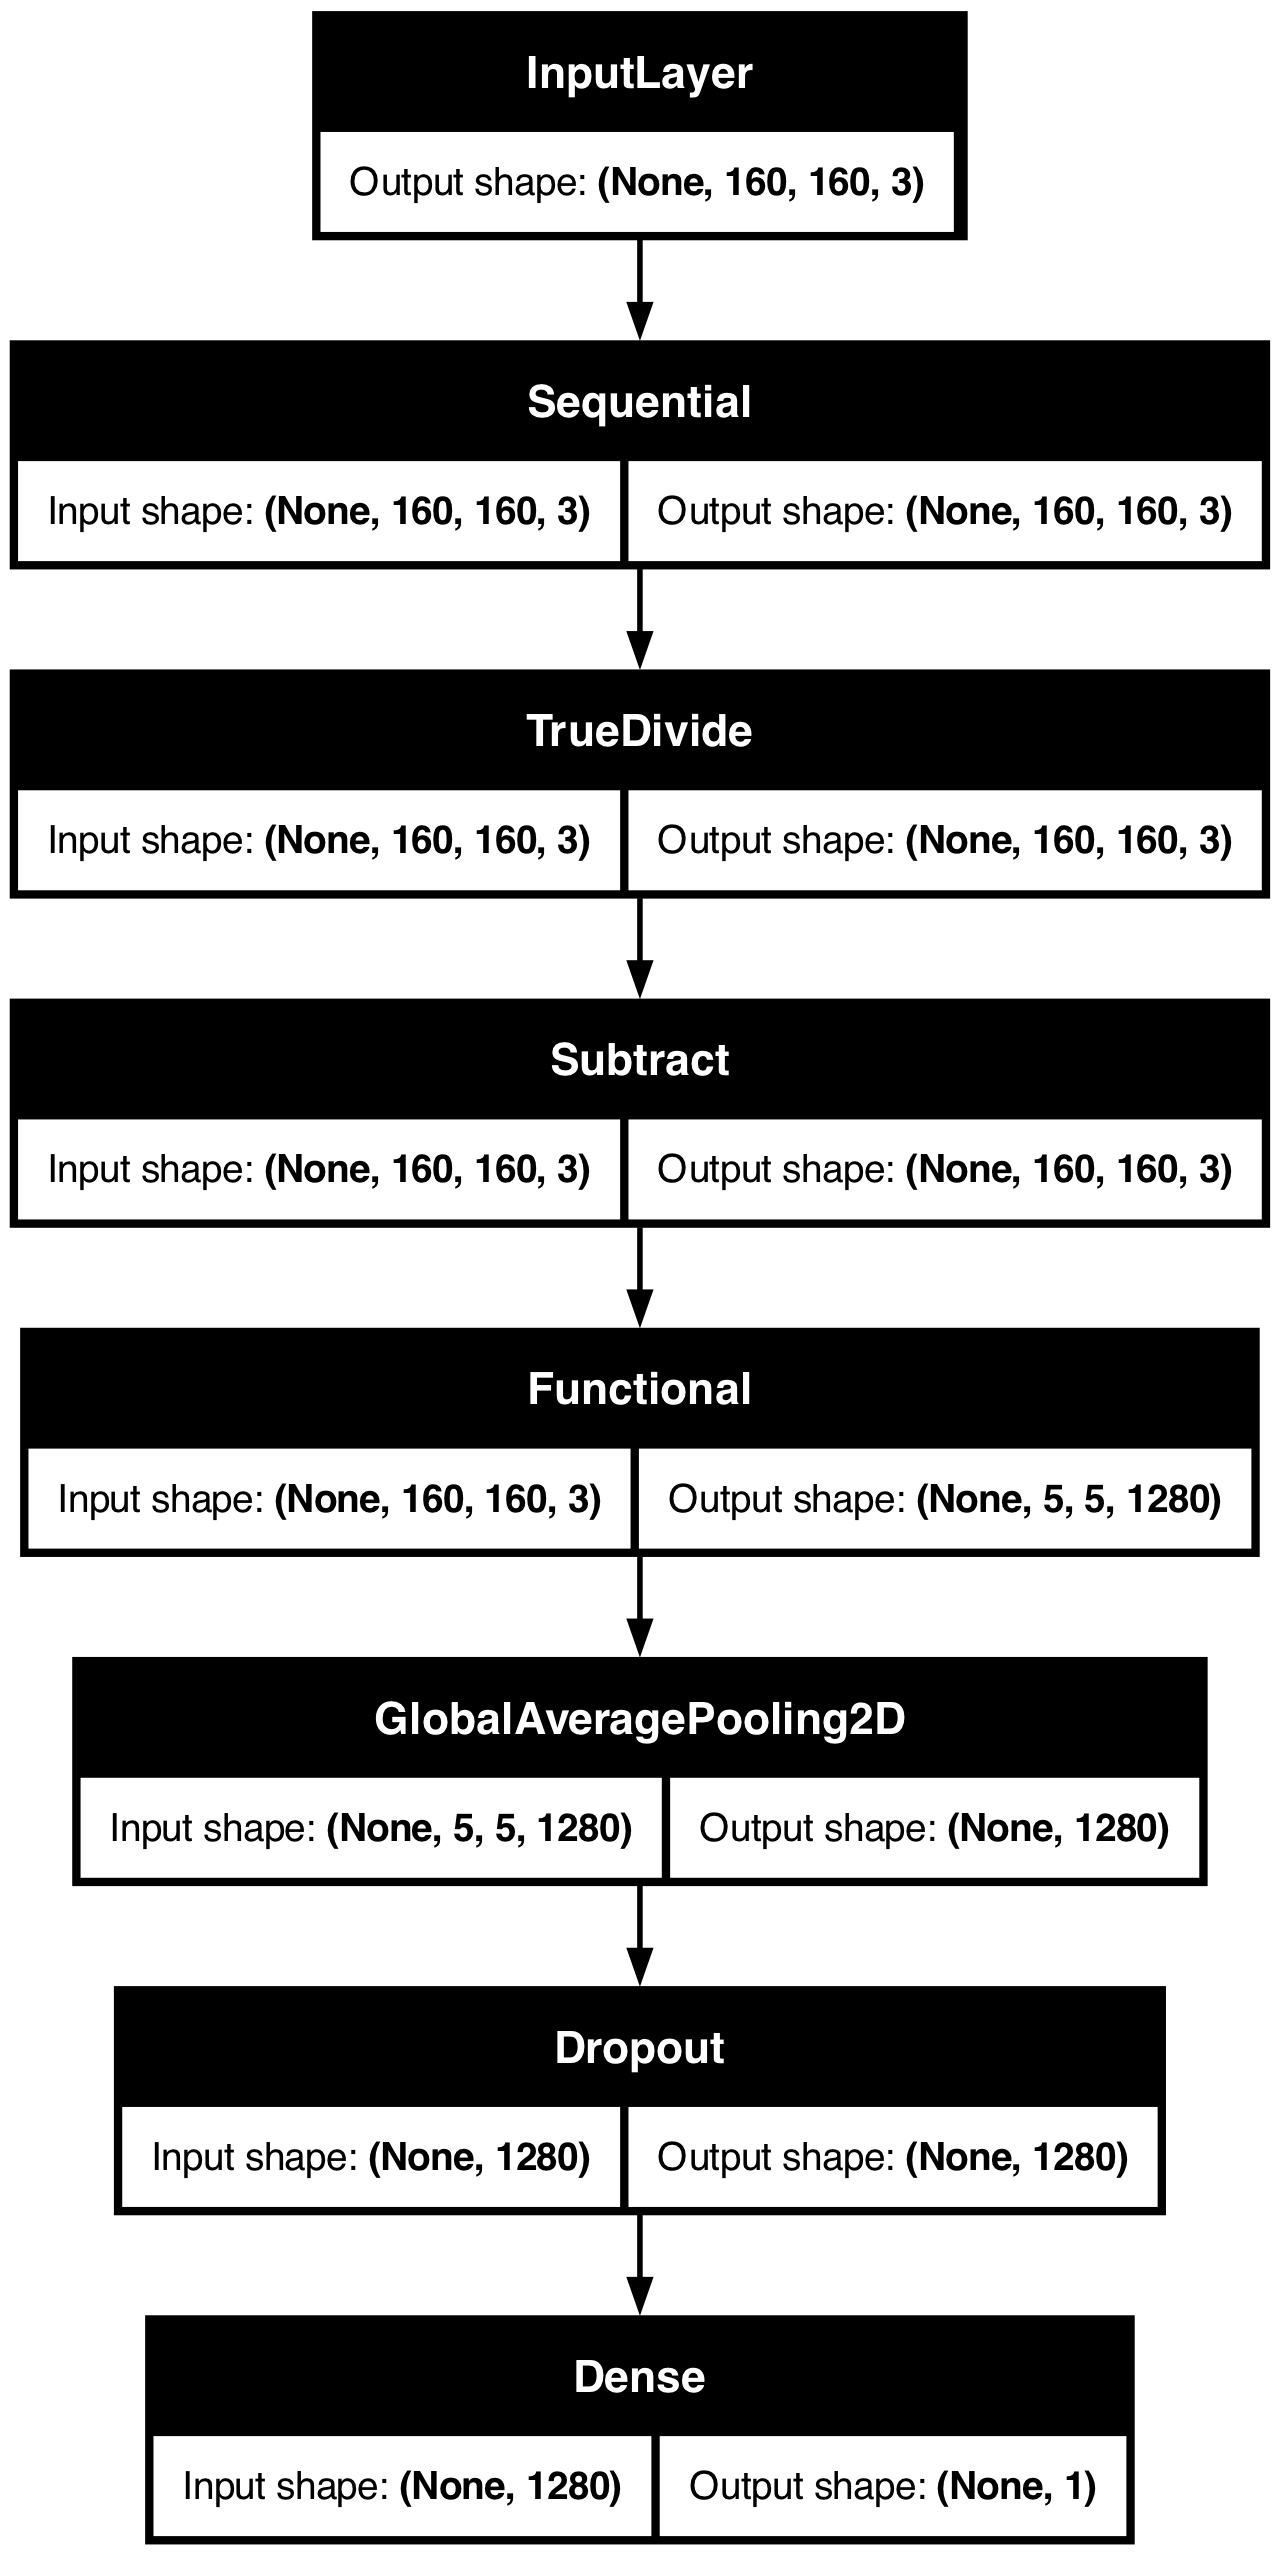

In [63]:
tf.keras.utils.plot_model(model, show_shapes=True)


In [64]:
model.compile(loss=tf.keras.losses.BinaryCrossentropy(), optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), metrics=[tf.keras.metrics.BinaryAccuracy(name="bin_accuracy", threshold=0.5)])


In [65]:
model.evaluate(test_ds)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 580ms/step - bin_accuracy: 0.4375 - loss: 0.8406


[0.8406369686126709, 0.4375]

In [66]:
initial_epochs = 10
history  = model.fit(train_ds, validation_data=val_ds, epochs=initial_epochs)

Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 101ms/step - bin_accuracy: 0.7247 - loss: 0.5201 - val_bin_accuracy: 0.9643 - val_loss: 0.1540
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 103ms/step - bin_accuracy: 0.9177 - loss: 0.2069 - val_bin_accuracy: 0.9762 - val_loss: 0.1199
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 102ms/step - bin_accuracy: 0.9101 - loss: 0.1845 - val_bin_accuracy: 0.9643 - val_loss: 0.1159
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 104ms/step - bin_accuracy: 0.9244 - loss: 0.1678 - val_bin_accuracy: 0.9643 - val_loss: 0.1018
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 111ms/step - bin_accuracy: 0.9437 - loss: 0.1490 - val_bin_accuracy: 0.9643 - val_loss: 0.0958
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 107ms/step - bin_accuracy: 0.9481 - loss: 0.1315 - val_bin_accuracy: 0.9643 - val_loss: 0.0860
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 100ms/step - bin_accuracy: 0.9616 - loss: 0.1137 - val_bin_accuracy: 0.9702 - val_loss: 0.0704
Epoch 8/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 107ms/s

In [68]:
history.history.keys()

dict_keys(['bin_accuracy', 'loss', 'val_bin_accuracy', 'val_loss'])

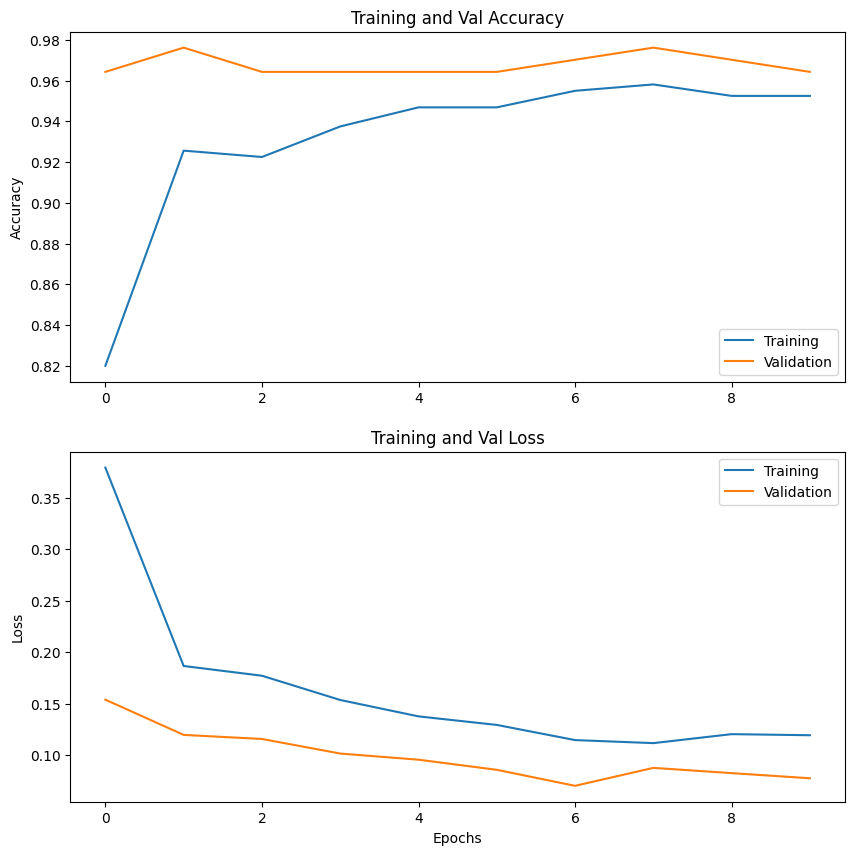

In [83]:
## Plot the accuracy
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))

plt.subplot(2,1,1)
plt.ylabel("Accuracy")
plt.plot(history.history["bin_accuracy"], label="Training")
plt.plot(history.history["val_bin_accuracy"], label ="Validation")
plt.title("Training and Val Accuracy")

plt.legend()

plt.subplot(2,1,2)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.plot(history.history["loss"], label="Training")
plt.plot(history.history["val_loss"], label ="Validation")
plt.title("Training and Val Loss")
plt.legend()
plt.show()

